# UPF XGBoost v3 (shared version)

This notebook loads a shared pickle bundle stored in the same folder.
It includes both XGBoost variants from the private workflow:
- base time-feature model
- lagged 15-minute model

In [3]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd

MODEL_BUNDLE = Path("upf_xgboost_models.pkl")
MODEL_BUNDLE.resolve()

PosixPath('/home/i2catf495/Documents/i2catProjects/O-RAN/BeGreen/MLStrategy/protectted/repo/FinalScripts/upf_xgboost_models.pkl')

In [4]:
if not MODEL_BUNDLE.exists():
    raise FileNotFoundError(f"Pickle bundle not found: {MODEL_BUNDLE.resolve()}")

with MODEL_BUNDLE.open("rb") as fh:
    bundle = pickle.load(fh)

base_bundle = bundle["base_model"]
lagged_bundle = bundle["lagged_model"]

metadata = {
    "artifact_type": bundle["artifact_type"],
    "created_at_utc": bundle["created_at_utc"],
    "frequency": bundle["frequency"],
    "base_test_rows": base_bundle["test_rows"],
    "lagged_test_rows": lagged_bundle["test_rows"],
}
metadata

{'artifact_type': 'xgboost_model_bundle',
 'created_at_utc': '2026-03-13T11:52:56.856776+00:00',
 'frequency': '15min',
 'base_test_rows': 2874,
 'lagged_test_rows': 2873}

In [5]:
forecast_base = base_bundle["reference_forecast"].copy()
forecast_lagged = lagged_bundle["reference_forecast"].copy()

print(f"base rows = {len(forecast_base)}")
print(f"lagged rows = {len(forecast_lagged)}")

forecast_base.tail()

base rows = 2874
lagged rows = 2873


,ds,y_XGBoost
2869,2023-10-31 23:00:00,80274.210938
2870,2023-10-31 23:15:00,78717.640625
2871,2023-10-31 23:30:00,75717.671875
2872,2023-10-31 23:45:00,72389.640625
2873,2023-11-01 00:00:00,65547.757812


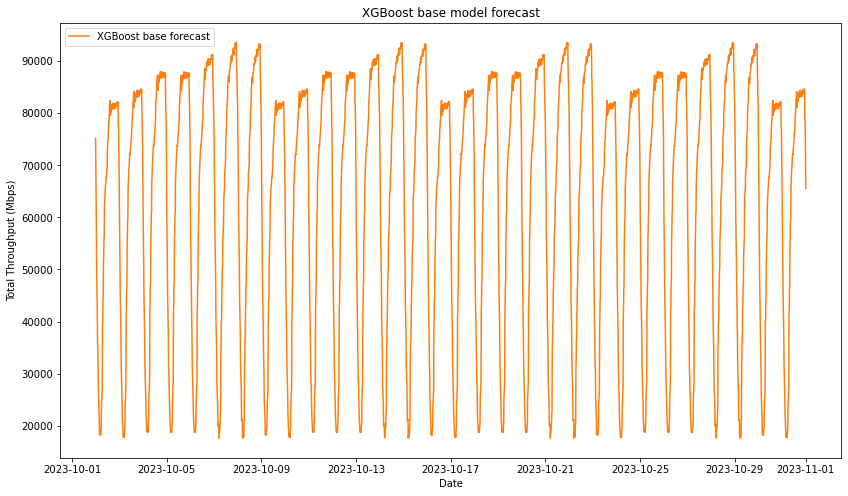

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
x_base = pd.to_datetime(forecast_base["ds"]).to_numpy()
y_base = forecast_base["y_XGBoost"].to_numpy()

ax.plot(x_base, y_base, label="XGBoost base forecast", color="tab:orange")
ax.set_title("XGBoost base model forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Total Throughput (Mbps)")
ax.legend()
plt.show()

In [7]:
forecast_lagged.tail()

,ds,y_XGBoost_lag15
2868,2023-10-31 23:00:00,86747.406250
2869,2023-10-31 23:15:00,85181.437500
2870,2023-10-31 23:30:00,84482.773438
2871,2023-10-31 23:45:00,82231.117188
2872,2023-11-01 00:00:00,79063.906250


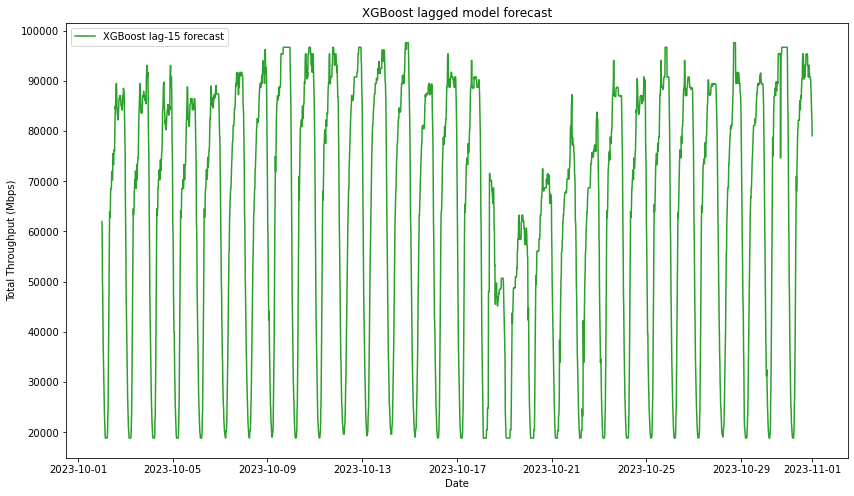

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
x_lag = pd.to_datetime(forecast_lagged["ds"]).to_numpy()
y_lag = forecast_lagged["y_XGBoost_lag15"].to_numpy()

ax.plot(x_lag, y_lag, label="XGBoost lag-15 forecast", color="tab:green")
ax.set_title("XGBoost lagged model forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Total Throughput (Mbps)")
ax.legend()
plt.show()

In [9]:
comparison = forecast_base.merge(forecast_lagged, on="ds", how="inner")
comparison.tail()

,ds,y_XGBoost,y_XGBoost_lag15
2868,2023-10-31 23:00:00,80274.210938,86747.406250
2869,2023-10-31 23:15:00,78717.640625,85181.437500
2870,2023-10-31 23:30:00,75717.671875,84482.773438
2871,2023-10-31 23:45:00,72389.640625,82231.117188
2872,2023-11-01 00:00:00,65547.757812,79063.906250


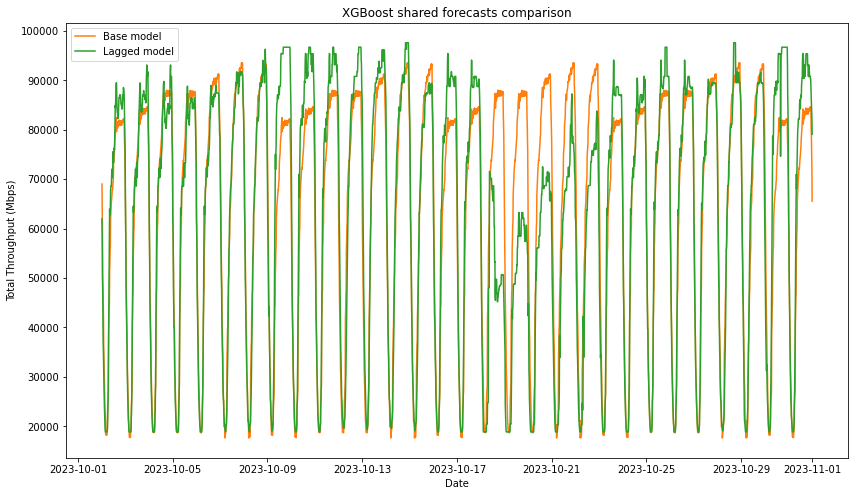

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))
x_cmp = pd.to_datetime(comparison["ds"]).to_numpy()
y_base = comparison["y_XGBoost"].to_numpy()
y_lag = comparison["y_XGBoost_lag15"].to_numpy()

ax.plot(x_cmp, y_base, label="Base model", color="tab:orange")
ax.plot(x_cmp, y_lag, label="Lagged model", color="tab:green")
ax.set_title("XGBoost shared forecasts comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Total Throughput (Mbps)")
ax.legend()
plt.show()

In [11]:
forecast_base.to_csv("xgboost_base_shared_forecast.csv", index=False)
forecast_lagged.to_csv("xgboost_lagged_shared_forecast.csv", index=False)
comparison.to_csv("xgboost_shared_comparison.csv", index=False)
"Saved CSV files in current folder"

'Saved CSV files in current folder'

## Notes

- The original oracle values are not included in the shared pickle.
- Both trained models are stored in the same bundle file: `upf_xgboost_models.pkl`.
- Keep the notebook and the pickle in the same folder when sharing.